# Evaluation on Modes of Climate Variability: Pacific North-Atlantic Bias

# Libraries

In [1]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import TwoSlopeNorm
from typing import Dict, Tuple, AnyStr
from matplotlib import pyplot as plt
from shapely.geometry import Polygon
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import matplotlib.path as mpath
import cartopy.util as cutil
import cartopy.crs as ccrs
import matplotlib.cm as cm
import seaborn as sns
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import torch
import pywt 
import json
import glob
import cv2
import os

os.chdir('../..')

from wavesim.metrics import NormalizedRootMeanSquaredError, DataStructuralSimilarityIndex
from wavesim.utils import dataframe_to_markdown_table
from wavesim import WaveSim

%load_ext autoreload
%autoreload 2

# Data

In [2]:
# Build 'DJF year' label: December belongs to the *previous* year's DJF
def get_djf_year(time):
    return xr.where(time.dt.month == 12, time.dt.year + 1, time.dt.year)

## Load Observations

In [3]:
years = np.arange(1979, 2015, 1) # 37 years
months = [12, 1, 2] # DJF

### OBS ###
level = 500.0
obs_path = 'data/reanalysis/hgt.mon.mean.73x144.nc'
Z500_obs = xr.open_dataset(obs_path).sel(level = level)
Z500_obs = Z500_obs.sortby('time')

tmp = Z500_obs.where(Z500_obs['time'].dt.month.isin(months), drop=True)
tmp.coords['djf_year'] = get_djf_year(tmp['time'])
tmp = tmp.sel(time=tmp['djf_year'].isin(years))
DJF_seasonal = tmp.groupby('djf_year').mean(dim='time')     # shape: (djf_year, lat, lon)

lons = DJF_seasonal.lon.values
lats = DJF_seasonal.lat.values
lons, lats = np.meshgrid(lons, lats)

Z500_obs_mean = DJF_seasonal.mean(dim='djf_year')['hgt']    # shape: (lat, lon)

## Load Earth System Model Data

In [4]:
var = 'zg'
esm_base_path = f'data/CMIP6_monthly_data/remapped/{var}'
#ESM = ['CESM2', 'CMCC-CM2-HR4', 'GFDL-ESM4'] #, 'MIROC6']
ESM = ['CESM2-FV2', 'CMCC-CM2-HR4', 'GFDL-ESM4']
#ESM = ['CESM2-WACCM', 'CMCC-CM2-HR4', 'GFDL-ESM4']
interannual_ESM = {}
plev = 50000.
###

for esm in ESM:
    esm_path = glob.glob(f'{esm_base_path}/{esm}_{var}_*.nc')[0]
    esm_df = xr.open_dataset(esm_path)
    esm_df = esm_df.sortby('time')

    # select the geopotential level
    esm_df = esm_df.sel(plev = plev)

    # Convert the time format
    try:
        formatted_times = [pd.to_datetime(t.strftime('%Y-%m-%dT%H:%M:%S') + '.000000000') for t in esm_df['time'].values]
        formatted_times = np.array(formatted_times, dtype='datetime64[ns]')
        esm_df.coords['time'] = ('time', formatted_times)
    except:
        pass

    # Select months in DJF
    tmp = esm_df.where(esm_df['time'].dt.month.isin(months), drop=True)
    # Build 'DJF year' label: December belongs to the *previous* year's DJF
    tmp.coords['djf_year'] = get_djf_year(tmp['time'])
    # Select only DJFs that fall within 1979–2014
    tmp = tmp.sel(time=tmp['djf_year'].isin(years))
    # Now compute seasonal DJF mean for each DJF year
    DJF_seasonal = tmp.groupby('djf_year').mean(dim='time')     # (djf_year, lat, lon)
    # Compute climatology (1979–2014 average)
    interannual_DJF = DJF_seasonal.mean(dim='djf_year')         # (lat, lon)

    interannual_ESM[esm] = interannual_DJF[var]

list(interannual_ESM.keys())

['CESM2-FV2', 'CMCC-CM2-HR4', 'GFDL-ESM4']

# Plot : Figure 3 of the Paper

0 CESM2-FV2
1 CMCC-CM2-HR4
2 GFDL-ESM4


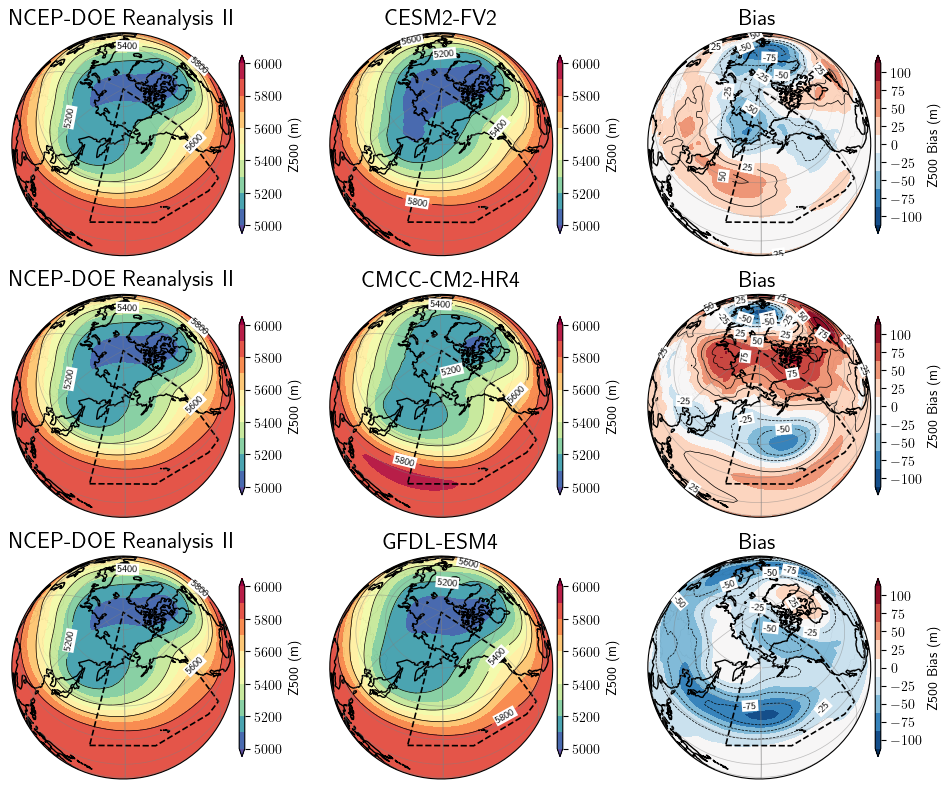

In [5]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

fig, axs = plt.subplots(len(ESM), 3, figsize=(10, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=179, central_latitude=60.25)})

vmin, vmax = 5000, 6000
#levels_obs = np.arange(vmin, vmax + 1, 50)  # fine for contours
levels_obs = np.arange(vmin, vmax + 1, 100)  # fine for contours
ticks_obs = np.arange(vmin, vmax + 1, 200)  # coarser for colorbar

vmin_bias, vmax_bias = -100, 100
step = 25
boundaries = np.arange(-112.5, 112.6, step) #np.arange(vmin_bias, vmax_bias + step, step)
ticks_bias = np.arange(vmin_bias, vmax_bias + 1, step)
#n_bins = len(boundaries) - 1
#cmap_base = plt.get_cmap('RdBu_r', n_bins)
#colors = cmap_base(np.linspace(0, 1, n_bins))
#zero_bin_index = np.where((boundaries[:-1] < 0) & (boundaries[1:] > 0))[0][0]  # Find bin that spans 0
#colors[zero_bin_index] = [1, 1, 1, 1]  # white
#colors[n_bins // 2] = [1, 1, 1, 1]  # set center bin to pure white
#cmap_custom = ListedColormap(colors)
#norm = TwoSlopeNorm(vmin=vmin_bias, vcenter=0.0, vmax=vmax_bias)
#norm = BoundaryNorm(boundaries, ncolors=n_bins)

# for circle-style plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Coordinates for bounding box
lon_min, lon_max = 161, 240
lat_min, lat_max = 12.5, 90
box_coords = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max), (lon_min, lat_min)]
box = Polygon(box_coords)

for i, esm in enumerate(ESM):
    print(i, esm)
    obs = Z500_obs_mean  # Observational climatology
    esm_map = interannual_ESM[esm]  # Model climatology
    bias_map = (esm_map - obs)
    for j, data in enumerate([obs, esm_map, bias_map]):
        ax = axs[i, j]
        data_cyc, lons_, lats_ = cutil.add_cyclic(data, lons, lats)
        
        if j == 2:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            #im = ax.contourf(lons_, lats_, data_cyc, levels=boundaries, cmap=cmap_custom, norm=norm, extend='both', transform=ccrs.PlateCarree())
            im = ax.contourf(lons_, lats_, data_cyc, levels=boundaries, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
            contour_levels = [-100, -75, -50, -25, 25, 50, 75, 100]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', ticks=ticks_bias)
            cbar.set_label('Z500 Bias (m)')
            #contour_levels = [-100, -50, -25, 25, 50, 100]
        elif j == 1:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=levels_obs, cmap='Spectral_r', extend='both', transform=ccrs.PlateCarree()) # Spectral_r
            contour_levels = [5000, 5200, 5400, 5600, 5800, 6000]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, linestyles='solid', transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', extend='both', ticks=ticks_obs)
            cbar.set_label(label='Z500 (m)')
        else:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=levels_obs, cmap='Spectral_r', extend='both', transform=ccrs.PlateCarree()) # Spectral_r
            contour_levels = [5000, 5200, 5400, 5600, 5800, 6000]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, linestyles='solid', transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', extend='both', ticks=ticks_obs)
            cbar.set_label(label='Z500 (m)')

        ax.add_geometries([box], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.2, linestyle='dashed')
        clabels = ax.clabel(CS, inline=True, inline_spacing=5, fontsize=7, fmt='%d')
        for txt in clabels:
            txt.set_bbox(dict(facecolor='white', edgecolor='none', pad=1.0))

        title = f"{'NCEP-DOE Reanalysis II' if j==0 else (f'{esm}' if j==1 else f'Bias')}"
        ax.set_title(title, fontsize=16)
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, linewidth=0.1)
        ax.set_boundary(circle, transform=ax.transAxes)
        
# Shared colorbar
#cax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
#fig.colorbar(im, ax=axs.ravel().tolist(), cax=cax, orientation='horizontal', ticks=ticks, label='Z500 (m)')
plt.subplots_adjust(
    left=0.05, right=0.95, top=0.95, bottom=0.05,
    wspace=0.27,  # horizontal space between columns, reduce from default (~0.2)
    hspace=0.3   # vertical space between rows, reduce from default (~0.2)
)
plt.tight_layout(rect=[0, 0, 1, 1])
#plt.show()
plt.savefig('figures/fig3.png', dpi=300)

# Benchmark

In [6]:
wavesim_params = {'wavelet': 'db2',
                'mode': 'symmetric',
                'levels': 3,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                'scales_weight': [0.333, 0.333, 0.333], # TODO : transform in a tensor (B, C, L+1)
                #'scales_weight': [0.25, 0.25, 0.25, 0.25], # TODO : transform in a tensor (B, C, L+1)
                'use_approx' : False,
                }

#nrsme_params = {'mode' : 'range'}
nrsme_params = {'p' : 1}

dssim_params = {'C1' : 1.0e-8, 
                'C2' : 1.0e-8, 
                'k' : 5, 
                'x_stddev' : 1.5, 
                'x_size' : 11, 
                'y_size' : 11, 
                'discretize' : True,
                'return_contrast' : False}

## Scores DataFrame

In [7]:
scores = pd.DataFrame(columns=['Earth System Model', 
                               'nrmse', 
                               'dssim', 
                               'wavesim',
                               'wavesim_components',
                               ]).astype({
                                        'Earth System Model': 'str', 
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                                        })

## Run the Benchmark and get metrics scores

In [8]:
# Convert numpy arrays → Python lists, then to JSON string
def to_jsonable(d):
    return {k: v.tolist() for k, v in d.items()}

In [9]:
dec_precision = 2

In [10]:
Z500_obs_pna = torch.Tensor(Z500_obs_mean.sel(lat=slice(90, 12.5), lon=slice(161, 240)).values.copy()).unsqueeze(0).unsqueeze(0)

for _, esm in enumerate(ESM):  
    print(f'Processing {esm}...')
    Z500_esm_pna = torch.Tensor(interannual_ESM[esm].sel(lat=slice(90, 12.5), lon=slice(161, 240)).values.copy()).unsqueeze(0).unsqueeze(0)

    nrmse_score = NormalizedRootMeanSquaredError(map1=Z500_obs_pna, map2=Z500_esm_pna, params=nrsme_params).compute()
    dssim_score = DataStructuralSimilarityIndex(map1=Z500_obs_pna, map2=Z500_esm_pna, params=dssim_params).compute()
    
    wavesim = WaveSim(map1=Z500_obs_pna, map2=Z500_esm_pna, params=wavesim_params)
    
    
    wavesim_score = wavesim.compute()
    # TODO : wavesim components should be np.arrays to be easily converted from str to dict of np.arrays 
    wavesim_components = {'magnitude': wavesim.magnitude_sim_score.numpy().ravel(),
                          'displacement': wavesim.displacement_sim_score.numpy().ravel(), 
                          'structure' : wavesim.structural_sim_score.numpy().ravel()
                          }
    
    # convert dict to json string
    wavesim_components_json = json.dumps(to_jsonable(wavesim_components))
    
    new_row = pd.DataFrame({'Earth System Model' : [esm],
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_score],
                                'wavesim_components' : [wavesim_components_json]
                                })

    scores = pd.concat([scores, new_row], ignore_index=True)

Processing CESM2-FV2...
Processing CMCC-CM2-HR4...
Processing GFDL-ESM4...


## Save to CSV

In [12]:
scores.to_csv('examples/case_studies/pna_bias_scores.csv', index=False)

## Save to Markdown

In [13]:
dataframe_to_markdown_table(scores, 'examples/case_studies/pna_bias_scores.md')

Markdown table saved to examples/case_studies/pna_bias_scores.md


In [14]:
scores = pd.read_csv('/Users/gabrieleaccarino/Workspace/wavesim/examples/case_studies/synthetic_cases_spatial_scores.csv')

# Heatmap

In [15]:
path = '/Users/gabrieleaccarino/Workspace/wavesim/examples/case_studies/pna_bias_scores.csv'
scores = pd.read_csv(path)

In [16]:
scores['wavesim_components'] = scores['wavesim_components'].apply(
    lambda s: {k: np.array(v, dtype=np.float32) for k, v in json.loads(s).items()}
)

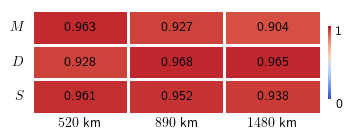

In [17]:
# Expand the nested data into a tidy (long) DataFrame
records = []
for _, row in scores.iterrows():
    esm = row["Earth System Model"]
    for component, values in row["wavesim_components"].items():
        for scale_idx, val in enumerate(values, start=1):
            records.append({
                "Earth System Model": esm,
                "component": component,
                "scale": f"Scale {scale_idx}",
                "value": val
            })
            
df_long = pd.DataFrame(records)

####################################

esm_to_plot = "CESM2-FV2"
plot_df = df_long[df_long["Earth System Model"] == esm_to_plot].copy()

# Map component names to LaTeX labels
component_map = {"magnitude": r"$M$", "displacement": r"$D$", "structure": r"$S$"}
# physical scales 
scale_map = {'Scale 1': r'$520$ km', 'Scale 2': r'$890$ km', 'Scale 3': r'$1480$ km'}

plot_df["component_label"] = plot_df["component"].map(component_map)
# Make 'component_label' a categorical variable with explicit order
plot_df["component_label"] = pd.Categorical(
    plot_df["component_label"],
    categories=list(component_map.values()),  # order as in your dict
    ordered=True
)

# Make 'scale_label' a categorical variable with explicit order
plot_df["scale_label"] = plot_df["scale"].map(scale_map)
plot_df["scale_label"] = pd.Categorical(
    plot_df["scale_label"],
    categories=list(scale_map.values()),  # order as in your dict
    ordered=True
)

# Pivot for heatmap: components on y-axis, scales on x-axis
pivot = plot_df.pivot(index="component_label", columns="scale_label", values="value")

cmap = 'coolwarm'

# --- Plot ---
plt.rcParams.update({"text.usetex": True})  # enable LaTeX rendering

# Plot heatmap
fig, ax = plt.subplots(figsize=(4, 1.5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidths=2,                                   # distance between blocks
    linecolor="white",                              # color of the separating lines
    annot_kws={"color": "black", "fontsize": 10},   # black numbers
    cbar=True,                                      # enable colorbar
    cbar_kws={"shrink": 0.7, "pad": 0.02}           # closer colorbar
)

# x-axis
ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, va="center")
ax.tick_params(axis='x', labelsize=10, length=0, pad = 7)  
ax.set_xlabel("")

# y-axis
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0, va="center")
ax.tick_params(axis='y', labelsize=10, length=0, pad = 6)
ax.set_ylabel("")

# Customize colorbar
cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0", "1"])
cbar.ax.tick_params(length=0)  # remove tick marks
cbar.ax.set_title("", pad=10)  # no title
#cbar.ax.set(title='high similarity', xlabel='low similarity', ylabel='')

# Move the labels just above and below the bar
for label in cbar.ax.get_yticklabels():
    label.set_verticalalignment("top")

plt.tight_layout()
plt.show()

# Plot : Figure 3 + Heatmaps

0 CESM2-FV2
1 CMCC-CM2-HR4
2 GFDL-ESM4


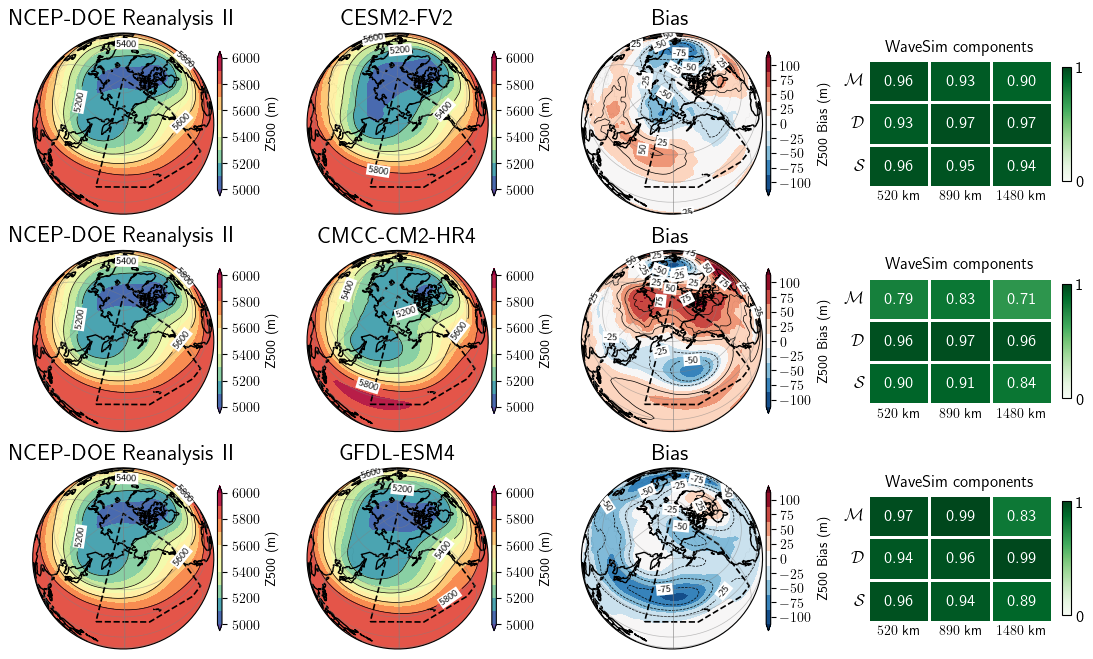

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from shapely.geometry import Polygon
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

# Expand the nested data into a tidy (long) DataFrame
records = []
for _, row in scores.iterrows():
    esm = row["Earth System Model"]
    for component, values in row["wavesim_components"].items():
        for scale_idx, val in enumerate(values, start=1):
            records.append({
                "Earth System Model": esm,
                "component": component,
                "scale": f"Scale {scale_idx}",
                "value": val
            })
            
df_long = pd.DataFrame(records)

######### Contours + Heatmap #########

# Setup figure with 4 columns now
fig, axs = plt.subplots(len(ESM), 4, figsize=(13, 8),
                        subplot_kw={'projection': ccrs.Orthographic(central_longitude=179, central_latitude=60.25)},
                        gridspec_kw={'width_ratios': [1, 1, 1, 0.8]} #, 'height_ratios': [1, 1, 0.5]}
                        )

# Make the last column normal axes (not geographic)
for i in range(len(ESM)):
    axs[i, 3].remove()  # remove cartopy axes placeholder
    axs[i, 3] = fig.add_subplot(len(ESM), 4, i*4 + 4)  # replace with normal Axes

vmin, vmax = 5000, 6000
levels_obs = np.arange(vmin, vmax + 1, 100)  # fine for contours
ticks_obs = np.arange(vmin, vmax + 1, 200)  # coarser for colorbar

vmin_bias, vmax_bias = -100, 100
step = 25
boundaries = np.arange(-112.5, 112.6, step)
ticks_bias = np.arange(vmin_bias, vmax_bias + 1, step)

# for circle-style plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Coordinates for bounding box
lon_min, lon_max = 161, 240
lat_min, lat_max = 12.5, 90
box_coords = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max), (lon_min, lat_min)]
box = Polygon(box_coords)

for i, esm in enumerate(ESM):
    print(i, esm)
    obs = Z500_obs_mean             # Observational climatology
    esm_map = interannual_ESM[esm]  # Model climatology
    bias_map = (esm_map - obs)
    for j, data in enumerate([obs, esm_map, bias_map]):
        ax = axs[i, j]
        data_cyc, lons_, lats_ = cutil.add_cyclic(data, lons, lats)
        
        if j == 2:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=boundaries, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
            contour_levels = [-100, -75, -50, -25, 25, 50, 75, 100]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', ticks=ticks_bias)
            cbar.set_label('Z500 Bias (m)')

        elif j == 1:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=levels_obs, cmap='Spectral_r', extend='both', transform=ccrs.PlateCarree()) # Spectral_r
            contour_levels = [5000, 5200, 5400, 5600, 5800, 6000]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, linestyles='solid', transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', extend='both', ticks=ticks_obs)
            cbar.set_label(label='Z500 (m)')
            
        else:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=levels_obs, cmap='Spectral_r', extend='both', transform=ccrs.PlateCarree()) # Spectral_r
            contour_levels = [5000, 5200, 5400, 5600, 5800, 6000]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, linestyles='solid', transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', extend='both', ticks=ticks_obs)
            cbar.set_label(label='Z500 (m)')

        ax.add_geometries([box], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.2, linestyle='dashed')
        clabels = ax.clabel(CS, inline=True, inline_spacing=5, fontsize=7, fmt='%d')
        for txt in clabels:
            txt.set_bbox(dict(facecolor='white', edgecolor='none', pad=1.0))

        title = f"{'NCEP-DOE Reanalysis II' if j==0 else (f'{esm}' if j==1 else f'Bias')}"
        ax.set_title(title, fontsize=16)
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, linewidth=0.1)
        ax.set_boundary(circle, transform=ax.transAxes)
    
    # --- disable first-column subplot for first and last row ---
    #if i == 0 or i == len(ESM) - 1:
    #    axs[i, 0].set_visible(False)
    #    axs[i, 0].set_axis_off()
        
    # Add the heatmap to last columm
    ax_hm = axs[i, 3]
    # get current [left, bottom, width, height]
    pos = ax_hm.get_position() 
    
    new_width = pos.width 
    new_height = pos.height * 0.7 
    new_x0 = pos.x0 + pos.width * 0.2
    new_y0 = pos.y0 + pos.height * 0.15
    
    ax_hm.set_position([new_x0, new_y0, new_width, new_height])

    plot_df = df_long[df_long["Earth System Model"] == esm].copy()
    component_map = {"magnitude": r"$\mathcal{M}$", "displacement": r"$\mathcal{D}$", "structure": r"$\mathcal{S}$"}
    scale_map = {'Scale 1': r'$520$ km', 'Scale 2': r'$890$ km', 'Scale 3': r'$1480$ km'}

    plot_df["component_label"] = pd.Categorical(plot_df["component"].map(component_map),
                                                categories=list(component_map.values()), ordered=True)
    
    plot_df["scale_label"] = pd.Categorical(plot_df["scale"].map(scale_map),
                                            categories=list(scale_map.values()), ordered=True)
    
    pivot = plot_df.pivot(index="component_label", columns="scale_label", values="value")

    hm = sns.heatmap(
        pivot,
        annot=True,
        fmt=f".{dec_precision}f",
        cmap="Greens",
        vmin=0,
        vmax=1,
        linewidths=1,
        linecolor="white",
        annot_kws={"color": "white", "fontsize": 12},
        cbar=False,  # disable per-row colorbar
        ax=ax_hm
    )

    # Format for compact display
    ax_hm.set_title("WaveSim components", fontsize=12, fontweight='bold')
    ax_hm.set_xlabel("")
    ax_hm.set_ylabel("")
    ax_hm.tick_params(axis='x', labelsize=10, length=0, pad=2)
    ax_hm.tick_params(axis='y', labelsize=12, length=0, pad=3)
    ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=0)
    ax_hm.set_yticklabels(ax_hm.get_yticklabels(), rotation=0)
    
    # Create a small colorbar axis next to the heatmap
    cax_hm = ax_hm.inset_axes([1.05, 0.05, 0.05, 0.9])  # [x0, y0, width, height] in relative coords
    cbar = fig.colorbar(ax_hm.collections[0], cax=cax_hm, orientation='vertical')
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["0", "1"])
    cbar.ax.tick_params(length=0, labelsize=12)
    cbar.ax.set_title("", pad=6)
    
#plt.show()
plt.savefig('figures/fig3_heatmap_1.png', dpi=300, bbox_inches="tight", pad_inches=0.15)
